In [101]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt

In [102]:
image = cv2.imread("../Data/Dog.jpg", cv2.IMREAD_GRAYSCALE)

In [103]:
mean = 0
sigma = 75

In [104]:
noise = np.random.normal(mean, sigma, image.shape)
noisy = image.astype(np.float32) + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

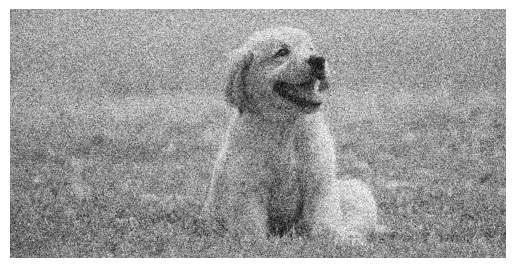

In [105]:
plt.imshow(noisy, cmap="gray")
plt.axis("off")
plt.show()

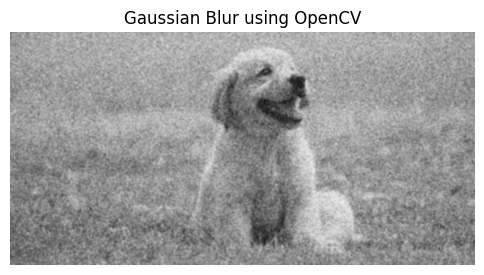

In [106]:
cv2_filtered = cv2.GaussianBlur( noisy, (7, 7), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2_filtered, cmap="gray")
plt.title("Gaussian Blur using OpenCV")
plt.axis("off")
plt.show()

In [107]:
def gaussian_filter(image, kernel_size=7, sigma=2):
    k = kernel_size // 2

    # Create Gaussian kernel
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)

    # Padding
    padded = np.pad( image, ((k, k), (k, k)), mode='edge')

    out_h, out_w = image.shape
    filtered = np.zeros((out_h, out_w), dtype=np.float32)

    # Convolution
    for i in range(out_h):
        for j in range(out_w):
            region = padded[i:i + kernel_size, j:j + kernel_size]
            filtered[i, j] = np.sum(region * kernel)

    return np.clip(filtered, 0, 255).astype(np.uint8)

In [108]:
my_filtered = gaussian_filter(
    noisy,
    kernel_size=7,
    sigma=2
)

plt.figure(figsize=(6, 6))
plt.imshow(my_filtered)
plt.title("Gaussian Filter - Our Implementation")
plt.axis("off")
plt.show()

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,2)  and requested shape (3,2)

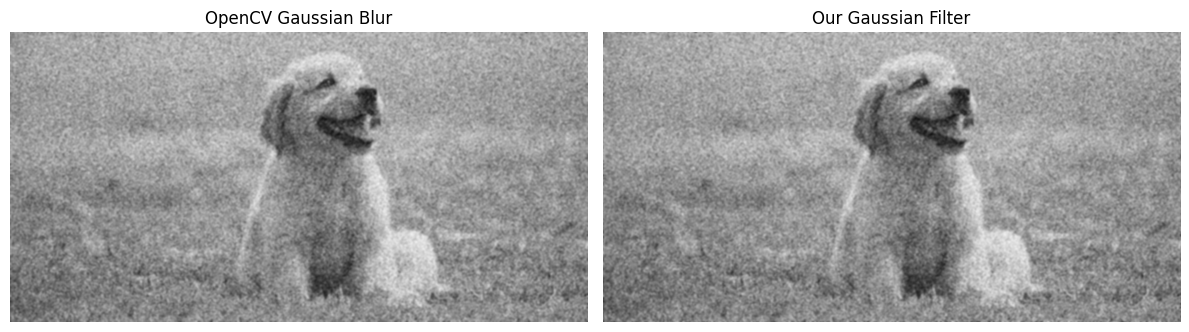

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2_filtered)
plt.title("OpenCV Gaussian Blur")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(my_filtered)
plt.title("Our Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()